# Grocery Data Pattern Mining Analysis

This notebook explores the grocery transaction dataset and implements pattern mining techniques to discover frequent itemsets and association rules. We'll explore the data first, then implement the pattern mining algorithm.

## 1. Data Exploration and Preprocessing
#### 1.1 Exploratory Data Analysis
#### 1.2 User Purchase Behavior Analysis
#### 1.3 Prepare Transaction Data for Pattern Mining



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from itertools import combinations
import math


import warnings #hide future warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Set plot style
plt.style.use('ggplot')
sns.set(font_scale=1.2)

In [2]:
# Load the training data
train_data = pd.read_csv('Groceries data train.csv')

# Check basic info
print(f"Dataset shape: {train_data.shape}")
train_data.head()


Dataset shape: (19382, 7)


,User_id,Date,itemDescription,year,month,day,day_of_week
0,2351,1/01/2014,cleaner,2014,1,1,2
1,2226,1/01/2014,sausage,2014,1,1,2
2,1922,1/01/2014,tropical fruit,2014,1,1,2
3,2943,1/01/2014,whole milk,2014,1,1,2
4,1249,1/01/2014,citrus fruit,2014,1,1,2


examine the data types and check for missing values:

In [3]:
# Data types and missing values
train_data.info()
print("\nMissing values:")
print(train_data.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User_id          19382 non-null  int64 
 1   Date             19382 non-null  object
 2   itemDescription  19382 non-null  object
 3   year             19382 non-null  int64 
 4   month            19382 non-null  int64 
 5   day              19382 non-null  int64 
 6   day_of_week      19382 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 1.0+ MB

Missing values:
User_id            0
Date               0
itemDescription    0
year               0
month              0
day                0
day_of_week        0
dtype: int64


convert the date to proper datetime format for analysis:

In [16]:
# Convert date to datetime
train_data['Date'] = pd.to_datetime(train_data['Date'], format='%d/%m/%Y')

# Add some temporal features
train_data['week'] = train_data['Date'].dt.isocalendar().week
train_data['month_name'] = train_data['Date'].dt.month_name()

# Verify date conversion
print("Date range:", train_data['Date'].min(), "to", train_data['Date'].max())
train_data.head()

Date range: 2014-01-01 00:00:00 to 2015-01-20 00:00:00


,User_id,Date,itemDescription,year,month,day,day_of_week,week,month_name
0,2351,2014-01-01,cleaner,2014,1,1,2,1,January
1,2226,2014-01-01,sausage,2014,1,1,2,1,January
2,1922,2014-01-01,tropical fruit,2014,1,1,2,1,January
3,2943,2014-01-01,whole milk,2014,1,1,2,1,January
4,1249,2014-01-01,citrus fruit,2014,1,1,2,1,January


The date conversion successfully transformed strings into datetime objects, with a confirmed date range of 2014-01-01 to 2015-01-20, giving us just over a year of data to analyze.

### __1.1 Exploratory Data Analysis__  
analyze the basic characteristics of our dataset:

In [28]:
# Number of unique users and items
print(f"Number of unique users: {train_data['User_id'].nunique()}")
print(f"Number of unique items: {train_data['itemDescription'].nunique()}")

# Count transactions (unique user-date combinations)
transactions = train_data.groupby(['User_id', 'Date'])['itemDescription'].count()
print(f"Number of transactions: {len(transactions)}")
print(f"Average items per transaction: {transactions.mean():.2f}")

Number of unique users: 3493
Number of unique items: 167
Number of transactions: 8361
Average items per transaction: 2.32


__=> This initial exploration reveals a medium-sized dataset with a reasonable number of users and a relatively limited product range. The average items per transaction (2.32) indicates that most purchases are quite small - typically 2-3 items per transaction, which is common in grocery or convenience store settings.__

In [32]:
# transactions = pd.DataFrame(transactions)
# transactions =transactions.reset_index()
transactions

User_id  Date      
1000     2014-06-24    3
1001     2014-07-02    3
         2014-12-12    2
         2015-01-20    2
1002     2014-04-26    2
                      ..
4997     2014-05-01    2
4999     2014-05-19    2
         2014-09-04    2
5000     2014-09-03    2
         2014-11-16    2
Name: itemDescription, Length: 8361, dtype: int64

In [33]:
transactions.value_counts()

itemDescription
2    6342
3    1472
4     491
5      26
6       8
8       8
1       5
7       5
9       4
Name: count, dtype: int64

* 6342 transactions contain exactly 2 items (most common)
* 1472 transactions contain 3 items
* 491 transactions contain 4 items
* 26 transactions contain 5 items
* A few transactions contain 6-9 items

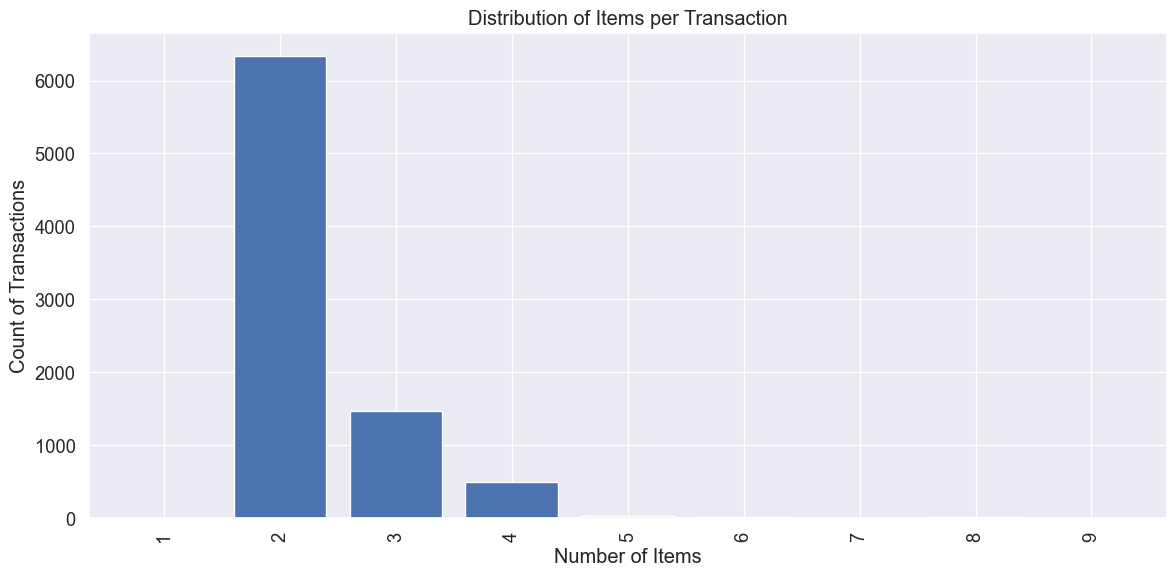

In [30]:
# Distribution of transaction sizes
plt.figure(figsize=(12, 6))
transactions.value_counts().sort_index().plot(kind='bar', width=0.8)
plt.title('Distribution of Items per Transaction')
plt.xlabel('Number of Items')
plt.ylabel('Count of Transactions')
plt.tight_layout()
plt.show()

* This distribution shows a strong preference for a relative small number of items per transactions, which could indicate:
    * This might be a convenience store dataset where customers typically buy only a few items per visit
    * The data might represent quick, frequent shopping trips rather than larger grocery runs
    * Customer behavior tends toward specific item pairs or small combinations rather than varied, large purchases

#### __Plot top 15 most frequent purchased items__

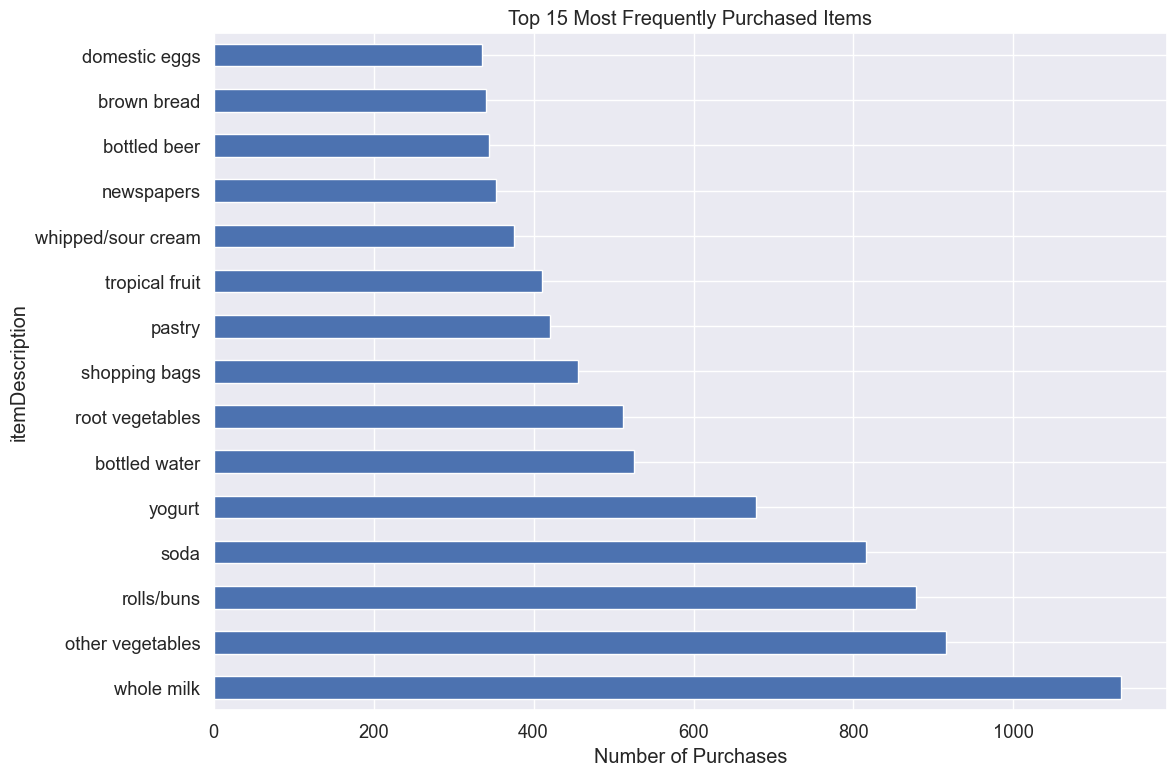

In [7]:
# Most frequent items
item_counts = train_data['itemDescription'].value_counts()
top_items = item_counts.head(15)

plt.figure(figsize=(12, 8))
top_items.plot(kind='barh')
plt.title('Top 15 Most Frequently Purchased Items')
plt.xlabel('Number of Purchases')
plt.tight_layout()
plt.show()

1. Whole milk is the most bought item with approximately 1,100 purchases, significantly outpacing all other items.
2. Other vegetables and rolls/buns follow as the second and third most popular items, with around 950 and 850 purchases respectively.
3. The data reveals a mix of essentials dominating purchases:
   - Dairy products: whole milk, yogurt, whipped/sour cream
   - Baked goods: rolls/buns, brown bread, pastry
   - Veggies: other vegetables, root vegetables, tropical fruit
   - Beverages: soda, bottled water, bottled beer

4. Essential household items like shopping bags and newspapers also appear in the top 15.
This distribution aligns with typical grocery shopping patterns, where dairy products (especially milk) are purchased frequently. The presence of vegetables, bread products, and beverages suggests this is likely data from a grocery store or supermarket rather than a specialty retailer.
The chart also indicates that the store's strongest categories are dairy, veggies, and bakery items, which could inform inventory management, store layout, and promotional strategies

In [8]:
# Show the percentage of total purchases
print("Top items as percentage of all purchases:")
total = len(train_data)
for item, count in top_items.items():
    print(f"{item}: {count/total*100:.2f}%")

Top items as percentage of all purchases:
whole milk: 5.86%
other vegetables: 4.73%
rolls/buns: 4.53%
soda: 4.21%
yogurt: 3.50%
bottled water: 2.71%
root vegetables: 2.64%
shopping bags: 2.35%
pastry: 2.17%
tropical fruit: 2.12%
whipped/sour cream: 1.94%
newspapers: 1.82%
bottled beer: 1.77%
brown bread: 1.76%
domestic eggs: 1.73%


* Even though whole milk is the most frequently purchased item, it only represents 5.86% of all purchases, indicating a highly diverse product range with purchases spread across many items.
* The top four items (whole milk, other vegetables, rolls/buns, and soda) each account for more than 4% of purchases, making them significantly more popular than other products.
* Despite being in the top 15, even common items like domestic eggs only make up 1.73% of all purchases.
* Together, these top 15 items account for approximately __41.84%__ of all purchases, meaning that the remaining __~58%__ of purchases are spread across the other 152 unique items in the dataset.

#### __Initial calculation of one-item sets support to choose a proper Support Threshold__

In [47]:
# Initial calculation of support of single items
item_frequencies = train_data.drop_duplicates()['itemDescription'].value_counts() # One item can be purchased twice in a single transaction
# calculate and print out top 15 highest Support
pd.DataFrame(item_frequencies/len(transactions)*100).head(15)

,count
itemDescription,
whole milk,13.048678
other vegetables,10.668580
rolls/buns,10.190169
soda,9.460591
yogurt,7.857912
bottled water,6.075828
root vegetables,6.039947
shopping bags,5.274489
pastry,4.963521


#### __Support Threshold Selection Strategy:__
The support values range from 13.05% (whole milk) down to 3.97% (domestic eggs) for the top 15 items, with the remaining 152 items having even lower support values. I believe a Support Threshold lies between 1-3% is a proper setting (for the time being) for these reasons:
* Setting it too high (for example 5%+) would eliminate most items from our analysis, including many potentially interesting association rules
* Setting it too low (e.g. <0.5%) might include very rare items that don't produce meaningful patterns and will significantly increase computational complexity  

Therefore, __a threshold around 2% would be a good balance because:__
* It would include all my top 15 items (which all have >3.9% support)
* It would likely capture between 30-50 items intotal (roughly 20-30% of all unique items)  
It's low enough to discover interesting patterns but high enough to filter out the noise from very rarely purchased items  

It's my assumptions at this current steps, but I may adjust this threshold if:
* There are __too many rules:__ increase to 2.5-3%
* __too few rules:__ decrease to 1-1.5%

__how purchases distribute across days of the week__

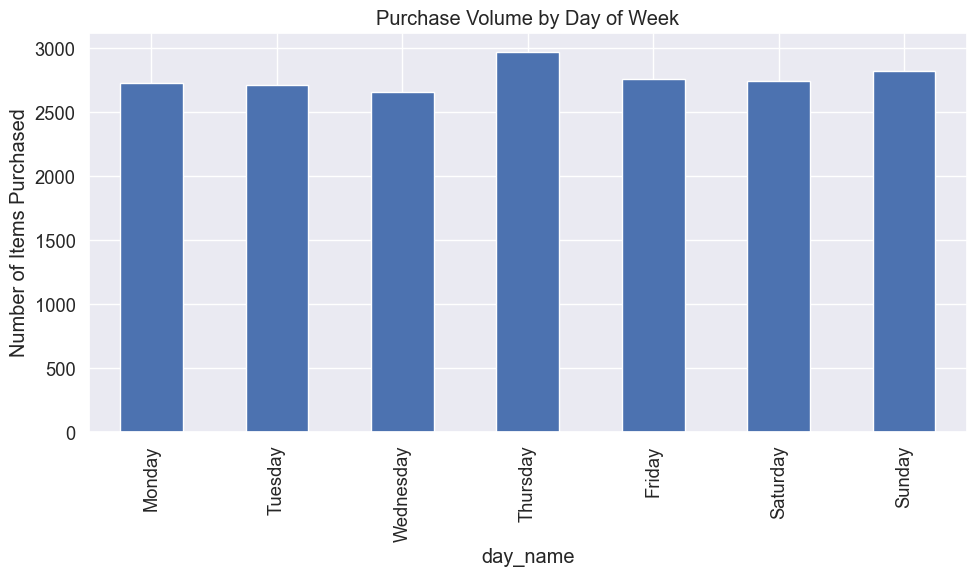

In [48]:
# Purchases by day of week
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 
             3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
train_data['day_name'] = train_data['day_of_week'].map(day_names)

plt.figure(figsize=(10, 6))
train_data['day_name'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).plot(kind='bar')
plt.title('Purchase Volume by Day of Week')
plt.ylabel('Number of Items Purchased')
plt.tight_layout()
plt.show()

* Thursday might be popular due to people stocking up before the weekend
* The slight weekend peak (Sunday) could represent major weekly grocery trips
* The relative consistency across days indicates this store maintains steady customer traffic rather than having extreme peaks

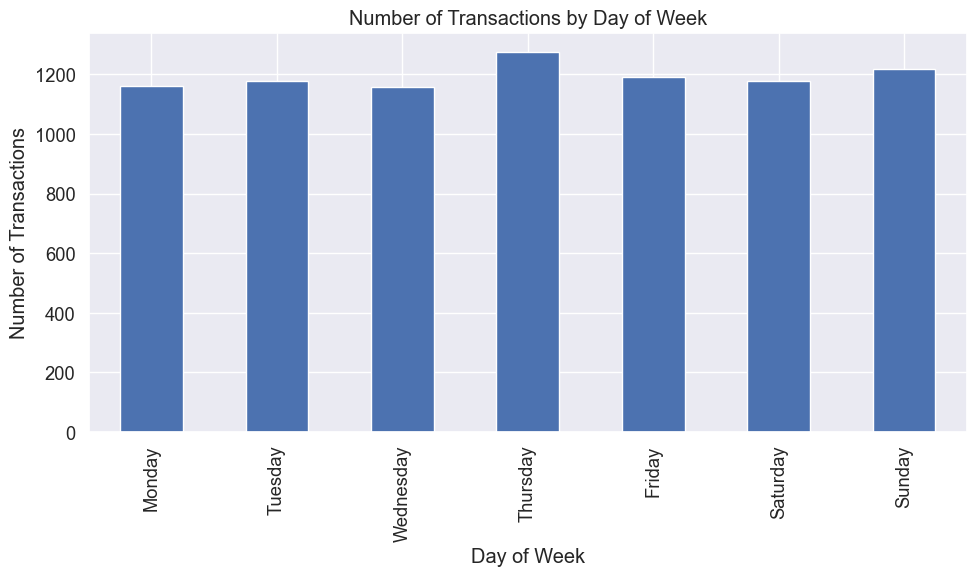

In [50]:

# Count unique transactions per day
# First, get unique (User_id, Date) combinations with their corresponding day
transaction_days = train_data[['User_id', 'Date', 'day_name']].drop_duplicates()

# Count transactions per day
transactions_per_day = transaction_days['day_name'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

# Plot
plt.figure(figsize=(10, 6))
transactions_per_day.plot(kind='bar')
plt.title('Number of Transactions by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

* The consistency between transaction count and purchase volume suggests that the average basket size is fairly stable across different days
* Thursday's prominence in both metrics confirms it as the most important day for store operations
* While Wednesday has fewer visitors, customers seem to purchase similar amounts per visit compared to other days
* The store experiences remarkably consistent traffic throughout the week, with less than 10% variation between the busiest and slowest days

__distribution of purchases across months:__

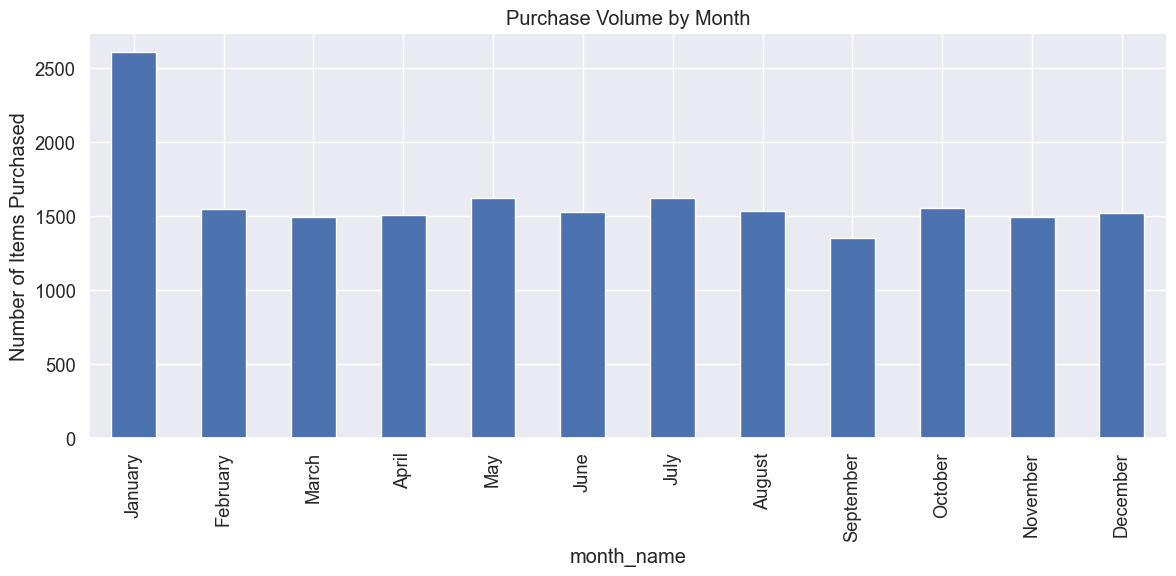

In [52]:
# Purchases by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
plt.figure(figsize=(12, 6))
train_data['month_name'].value_counts().reindex(month_order).plot(kind='bar')
plt.title('Purchase Volume by Month')
plt.ylabel('Number of Items Purchased')
plt.tight_layout()
plt.show()

* January has a significantly higher number of items purchased compared to other months. This is likely because the data collection period spans from January 1st, 2014 to January 20th, 2015, with a substantial portion of the data coming from the second January (2015). It also potentially captures post-holiday or New Year sale purchases
* The other months show relatively consistent purchase volumes, ranging between approximately 1,400 to 1,600 items per month. However, January stands out with around 2,500 items purchased, which is likely due to the data collection methodology and time range.

### __1.2 User Purchase Behavior Analysis__

examine how users behave in terms of purchase frequency:

c:\Users\ASUS\.conda\envs\myenv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


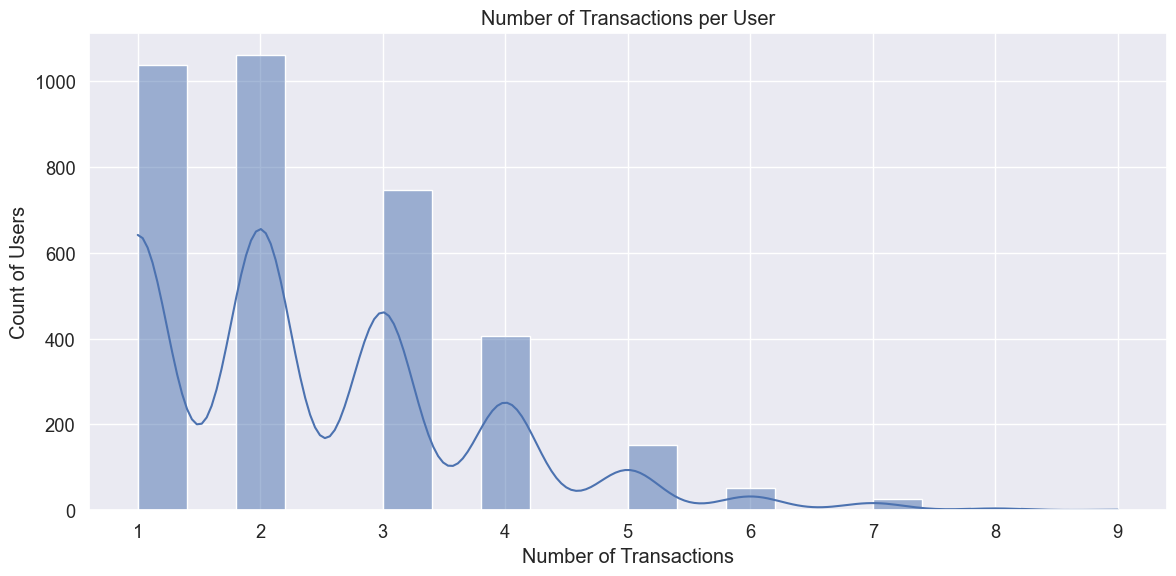

Average transactions per user: 2.39
Median transactions per user: 2.00
Max transactions per user: 9


In [53]:
# Transactions per user
user_transaction_counts = train_data.groupby('User_id')['Date'].nunique()

plt.figure(figsize=(12, 6))
sns.histplot(user_transaction_counts, bins=20, kde=True)
plt.title('Number of Transactions per User')
plt.xlabel('Number of Transactions')
plt.ylabel('Count of Users')
plt.tight_layout()
plt.show()

print(f"Average transactions per user: {user_transaction_counts.mean():.2f}")
print(f"Median transactions per user: {user_transaction_counts.median():.2f}")
print(f"Max transactions per user: {user_transaction_counts.max()}")

__The histogram shows a clear pattern of user purchasing behavior:__
* Most users make only 1-2 transactions, with these two categories having the highest counts (over 1,000 users each).
* There's a steady decline in the number of users as the transaction count increases.
* Very few users make more than 5 purchases.  
__The significant gap between median (2.00) and average (2.39) indicates the distribution is right-skewed, which is confirmed by the visualization.__

__patterns in the purchase time intervals:__

c:\Users\ASUS\.conda\envs\myenv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


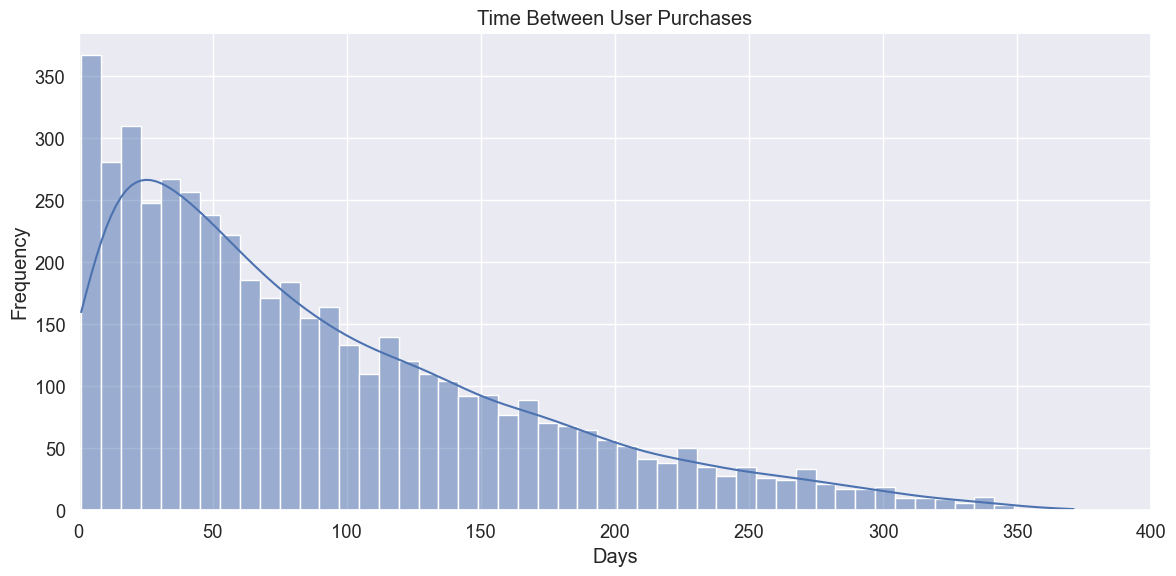

Average days between purchases: 90.42
Median days between purchases: 70.00


In [58]:
# Calculate time between purchases for each user
purchase_intervals = []
for user, group in train_data.groupby('User_id'):
    dates = sorted(group['Date'].unique())
    if len(dates) > 1:  # Only users with multiple purchase dates
        intervals = [(dates[i] - dates[i-1]).days for i in range(1, len(dates))]
        purchase_intervals.extend(intervals)

plt.figure(figsize=(12, 6))
sns.histplot(purchase_intervals, bins=50, kde=True)
plt.title('Time Between User Purchases')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.xlim(0, 400)  # Focus on shorter intervals
plt.tight_layout()
plt.show()

print(f"Average days between purchases: {np.mean(purchase_intervals):.2f}")
print(f"Median days between purchases: {np.median(purchase_intervals):.2f}")


* The highest frequency is for very short intervals (0-20 days)
* There's a gradual decline in frequency as the interval increases
* The distribution has a long tail extending all the way to around 350 days  
__It shows that while many customers make repeat purchases relatively quickly, there are still significant numbers who return after several months. The substantial difference between the mean (90.42) and median (70.00) confirms the right-skewed nature of this distribution.__

### __1.3 Prepare Transaction Data for Pattern Mining__  
Prepare our data in the right format for pattern mining:

In [67]:
def prepare_transactions(data):
    # Group by user and date
    transactions = defaultdict(list)
    for _, row in data.iterrows():
        key = (row['User_id'], row['Date']) # group item in the dataset by User_id and Date, name it as transaction
        if pd.notna(row['itemDescription']):  # Skip null items
            transactions[key].append(row['itemDescription'])
    
    # Convert to list of lists
    transaction_list = list(transactions.values())
    
    # Print some statistics
    transaction_sizes = [len(t) for t in transaction_list]
    print(f"Number of transactions: {len(transaction_list)}")
    print(f"Average transaction size: {np.mean(transaction_sizes):.2f} items")
    print(f"Largest transaction: {max(transaction_sizes)} items")
    
    return transaction_list

# Create transaction data
transactions = prepare_transactions(train_data)

Number of transactions: 8361
Average transaction size: 2.32 items
Largest transaction: 9 items


In [68]:
# Show a few sample transactions
print("\nSample transactions:")
for t in transactions[:5]:
    print(t)


Sample transactions:
['cleaner', 'shopping bags']
['sausage', 'bottled water']
['tropical fruit', 'other vegetables']
['whole milk', 'flower (seeds)']
['citrus fruit', 'coffee']


__This step transforms raw purchase data into a format where each transaction is represented as a set of items purchased together. Which will be used to apply Apriori to discover frequent itemsets and generate association rules that potentially reveal patterns in customer purchasing behavior.__

## 2. Implementing the Apriori Algorithm

In [ ]:
class AprioriMiner:
    """
    AprioriMiner: A class to find frequent itemsets and generate association rules
    using the Apriori algorithm.
    
    The Apriori algorithm works on the principle that if an itemset is frequent,
    then all of its subsets must also be frequent.
    """
    def __init__(self, min_support=0.005):
        """
        Initialize the AprioriMiner with minimum support threshold.
        
        Parameters:
        -----------
        min_support : float, default=0.005 (0.5%)
            The minimum support threshold. Items/itemsets with support less than
            this value will be discarded.
        """
        self.min_support = min_support
        self.transactions = None
        self.num_transactions = 0
        self.frequent_itemsets = {}
        self.item_support = {}
    
    # Find all frequent subsets
    def fit(self, transactions):
        """
        Find frequent itemsets using the Apriori algorithm.
        
        The algorithm works in multiple passes:
        1. First pass: count occurrences of individual items
        2. Filter by minimum support to get frequent 1-itemsets
        3. Subsequent passes: use frequent (k-1)-itemsets to generate candidate k-itemsets
        4. Filter candidates by minimum support to get frequent k-itemsets
        5. Continue until no more frequent itemsets can be found
        
        Parameters:
        -----------
        transactions : list of lists
            List of transactions, where each transaction is a list of items
        
        Returns:
        --------
        dict
            Dictionary with keys as itemset size and values as list of (itemset, support) tuples
        """
        self.transactions = transactions
        self.num_transactions = len(transactions)
        
        # Step 1: Count support for each individual item
        item_counts = defaultdict(int)
        for transaction in transactions:
            for item in set(transaction):  # Use set to count each item once per transaction
                item_counts[item] += 1
        
        # Filter by minimum support 
        ## get min count from min support
        min_count = self.min_support * self.num_transactions
        ## Convert items that meet min_count from count to support percentage
        self.item_support = {item: count/self.num_transactions for item, count in item_counts.items() 
                           if count >= min_count}
        
        # Initialize L1 (frequent 1-itemsets)
        ## Convert each item to a frozenset for consistent handling
        L1 = [frozenset([item]) for item in self.item_support.keys()]
        current_L = L1
        k = 1
        
        # Store all frequent itemsets
        self.frequent_itemsets = {
            k: [(itemset, self.item_support[list(itemset)[0]]) for itemset in L1] # k = number of items in an itemset
            # (itemset, support_itemset)
        }
        # ========================
        # Main Apriori loop
        ## Continue until no more frequent itemsets are found
        while current_L:
            k += 1
            # Generate candidate k-itemsets from frequent (k-1)-itemsets
            Ck = self._generate_candidates(current_L, k)
            
            if not Ck:
                break  # No candidates generated
                
            # Count support for candidates
            itemset_counts = defaultdict(int)
            for transaction in transactions:
                transaction_set = set(transaction)
                for candidate in Ck:
                    # For each candidate itemset, check if it's contained in the transaction
                    if candidate.issubset(transaction_set):
                        itemset_counts[candidate] += 1
            
            # Filter candidates by minimum support to get frequent k-itemsets (Lk)
            Lk = [itemset for itemset, count in itemset_counts.items() 
                 if count >= min_count]
            
            # Store k-itemsets with their support
            if Lk:
                self.frequent_itemsets[k] = [(itemset, itemset_counts[itemset]/self.num_transactions) 
                                           for itemset in Lk]
            
            # Prepare for next iteration 
            current_L = Lk
        
        return self.frequent_itemsets
    
    def _generate_candidates(self, prev_itemsets, k):
        """
        Generate candidate k-itemsets from (k-1)-itemsets using the join-prune approach.
        
        The join step combines pairs of (k-1)-itemsets that share (k-2) items.
        The prune step eliminates candidates where any (k-1) subset is not frequent.
        
        Parameters:
        -----------
        prev_itemsets : list
            List of frequent (k-1)-itemsets
        k : int
            Size of itemsets to generate
            
        Returns:
        --------
        list
            List of candidate k-itemsets
        """
        candidates = set()
        
        # For more efficient processing, convert to list of sets
        prev_sets = [set(itemset) for itemset in prev_itemsets]
        
        # For each pair of (k-1)-itemsets
        for i in range(len(prev_sets)):
            for j in range(i+1, len(prev_sets)):
                # Join step
                union = prev_sets[i].union(prev_sets[j])
                if len(union) == k:
                    # Check if all (k-1) subsets are frequent
                    is_valid = True
                    for item in union: # get subset including (k-1) items from current k-item set
                        # Every subset of this current set has to be frequent
                        subset = union - {item}
                        # If one of the subset of the current set is NOT frequent
                        if frozenset(subset) not in prev_itemsets: #[frozenset(s) for s in prev_itemsets]:
                            is_valid = False
                            break
                    
                    if is_valid:
                        candidates.add(frozenset(union)) 

        #================================
        #slower
        # items = set().union(*prev_sets)
            
        # combs = list(combinations(items, r= k))

        # for comb in combs:
        #     is_valid = True
        #     for item in comb:
        #         subset = set(comb) - {item}
        #         # print(subset)
        #         if frozenset(subset) not in prev_itemsets:
        #             is_valid = False
        #             break
        #     if is_valid:
        #         candidates.add(frozenset(comb))
        # Return all sets having k items whose all (k-1) subsets frequent
        return list(candidates)
    
    def generate_rules(self, min_confidence=0.5):
        """
        Generate association rules from frequent itemsets.
        
        An association rule X → Y is created where:
        - X (antecedent) and Y (consequent) are disjoint itemsets
        - X ∪ Y is a frequent itemset
        - The confidence (support(X ∪ Y) / support(X)) meets the threshold
        
        Parameters:
        -----------
        min_confidence : float, default=0.5 (50%)
            Minimum confidence threshold for rules
        
        Returns:
        --------
        list
            List of dictionaries containing rule information:
            {
                'antecedent': list of items,
                'consequent': list of items,
                'support': support of the itemset (antecedent ∪ consequent),
                'confidence': confidence of the rule (support(antecedent ∪ consequent) / support(antecedent)),
                'lift': lift of the rule (confidence / support(consequent))
            }
        """

        rules = []
        
        # Helper function to find support for an itemset
        def find_support(itemset):
            k = len(itemset)
            # for k in self.frequent_itemsets:
            for (candidate, support) in self.frequent_itemsets[k]:
                if candidate == itemset:
                    return support
            return 0  # Should not happen for frequent itemsets
        
        # For each k-itemset where k >= 2
        for k in self.frequent_itemsets:
            # Cannot create rules with a set of only 1 item
            if k < 2:
                continue
            # print('hi') 
            for itemset, itemset_support in self.frequent_itemsets[k]:
                
                # Generate all non-empty proper subsets
                subsets = []
                for i in range(1, k):
                    subsets.extend([frozenset(subset) for subset in combinations(itemset, i)])
                # print(subsets)
                # For each subset, create a rule (atecedent -> consequent)
                for antecedent in subsets: # Take the subsets array as array of all entecedents => itemset - antecedent = consequent set
                    consequent = itemset - antecedent
                    
                    # Skip empty consequents
                    if not consequent:
                        continue
                    
                    # A=>B: Calculate CONFIDENCE P(A, B) / P(A)
                    antecedent_support = find_support(antecedent)
                    confidence = itemset_support / antecedent_support
                    
                    # if confidence meet the requirement of min_confidence => calculate lift and add rule into rules array
                    if confidence >= min_confidence:
                        # A= > B: Calculate LIFT P(A, B) /(P(A)*P(B))
                        consequent_support = find_support(consequent)
                        lift = confidence / consequent_support
                        
                        rules.append({
                            'antecedent': list(antecedent),
                            'consequent': list(consequent),
                            'support': itemset_support,
                            'confidence': confidence,
                            'lift': lift
                        })
        
        return rules

__As mentioned above that 2-3% is my preferred ideal support threshold as 2-3% min support can cover roughly 40% of 1-item itemsets, I will loop through an array of possible support thresholds to come up with the most suitable threshold__

In [ ]:
# Run the Apriori algorithm on our transaction data
min_supports  = [3/100, 2/100, 1/100, 0.5/100, 0.1/100, 0.05/100, 0.02/100, 0.01/100 ]
for min_support in min_supports:
    miner = AprioriMiner(min_support=min_support)
    # find the frequent itemstes corresponding to each min support threshold
    frequent_itemsets = miner.fit(transactions)

    # Print the number of frequent itemsets by size
    print('-'*10)
    print(f"Min Support Threshold = {min_support*100}%")
    for k in sorted(frequent_itemsets.keys()):
        print(f"Number of frequent {k}-itemsets: {len(frequent_itemsets[k])}")

----------
Min Support Threshold = 3.0%
Number of frequent 1-itemsets: 23
----------
Min Support Threshold = 2.0%
Number of frequent 1-itemsets: 33
----------
Min Support Threshold = 1.0%
Number of frequent 1-itemsets: 62
----------
Min Support Threshold = 0.5%
Number of frequent 1-itemsets: 91
Number of frequent 2-itemsets: 10
----------
Min Support Threshold = 0.1%
Number of frequent 1-itemsets: 148
Number of frequent 2-itemsets: 314
----------
Min Support Threshold = 0.05%
Number of frequent 1-itemsets: 158
Number of frequent 2-itemsets: 761
Number of frequent 3-itemsets: 1
----------
Min Support Threshold = 0.02%
Number of frequent 1-itemsets: 163
Number of frequent 2-itemsets: 2230
Number of frequent 3-itemsets: 217
Number of frequent 4-itemsets: 3
----------
Min Support Threshold = 0.01%
Number of frequent 1-itemsets: 167
Number of frequent 2-itemsets: 4330
Number of frequent 3-itemsets: 4032
Number of frequent 4-itemsets: 1484
Number of frequent 5-itemsets: 689
Number of frequen

Choosing a minimum support of 0.02% for Apriori algorithm is a reasonable data exploration strategy that focuses on discovering rare but potentially valuable patterns. Here's the rationale:

1. **Capturing rare associations**: With our dataset of 8,361 transactions, a 0.02% minimum support threshold means an itemset needs to appear in approximately 1-2 transactions (0.0002 × 8,361 ≈ 1.7). This will capture very rare combinations that might be missed with higher thresholds.

2. **Rich pattern discovery**: Experiments showed that with minimum value of 0.02% support, we found:
   - 163 frequent 1-itemsets (individual items)
   - 2,230 frequent 2-itemsets (item pairs)
   - 217 frequent 3-itemsets (triplets)
   - 3 frequent 4-itemsets

3. **Complemented by confidence filtering**: When combined with a higher confidence threshold (50%), we will filter these numerous itemsets to focus only on those with strong associations, mitigating the risk of capturing coincidental patterns.


The trade-off is that we'll generate many more itemsets (approximately 2,613 total), which requires more computational resources and might include some coincidental patterns. However, with our dataset size and the subsequent filtering by confidence, this threshold should provide a good balance between discovering meaningful rare patterns and maintaining computational feasibility.

In [154]:
min_support = 0.02/100
miner = AprioriMiner(min_support=min_support)
frequent_itemsets = miner.fit(transactions)

# Print the number of frequent itemsets by size
print('-'*10)
print(f"Min Support Threshold = {min_support*100}%")
for k in sorted(frequent_itemsets.keys()):
    print(f"Number of frequent {k}-itemsets: {len(frequent_itemsets[k])}")

----------
Min Support Threshold = 0.02%
Number of frequent 1-itemsets: 163
Number of frequent 2-itemsets: 2230
Number of frequent 3-itemsets: 217
Number of frequent 4-itemsets: 3


In [ ]:
#print all frequent itemsets 
miner.frequent_itemsets

{1: [(frozenset({'shopping bags'}), 0.0527448869752422),
  (frozenset({'cleaner'}), 0.002272455447912929),
  (frozenset({'bottled water'}), 0.06075828250209305),
  (frozenset({'sausage'}), 0.02571462743690946),
  (frozenset({'tropical fruit'}), 0.048797990670972374),
  (frozenset({'other vegetables'}), 0.10668580313359646),
  (frozenset({'flower (seeds)'}), 0.005621337160626719),
  (frozenset({'whole milk'}), 0.1304867838775266),
  (frozenset({'coffee'}), 0.03061834708766894),
  (frozenset({'citrus fruit'}), 0.03456524339193876),
  (frozenset({'whipped/sour cream'}), 0.04437268269345772),
  (frozenset({'onions'}), 0.015787585217079295),
  (frozenset({'dishes'}), 0.008850615955029303),
  (frozenset({'yogurt'}), 0.07857911733046287),
  (frozenset({'berries'}), 0.016265996890324125),
  (frozenset({'hamburger meat'}), 0.017222820236813777),
  (frozenset({'frozen potato products'}), 0.005382131324004306),
  (frozenset({'candles'}), 0.004186102140892238),
  (frozenset({'Instant food products

In [156]:
# Print the number of frequent itemsets by size
for k in sorted(frequent_itemsets.keys()):
    print(f"Number of frequent {k}-itemsets: {len(frequent_itemsets[k])}")

Number of frequent 1-itemsets: 163
Number of frequent 2-itemsets: 2230
Number of frequent 3-itemsets: 217
Number of frequent 4-itemsets: 3


In [157]:
# Display top frequent itemsets by support
all_itemsets = []
for k in frequent_itemsets:
    all_itemsets.extend([(list(itemset), support, k) for itemset, support in frequent_itemsets[k]])

print("\nTop 20 frequent itemsets by support:")
for i, (itemset, support, size) in enumerate(sorted(all_itemsets, key=lambda x: x[1], reverse=True)[:20]):
    print(f"{i+1}. {itemset} (size: {size}, support: {support:.4f})")


Top 20 frequent itemsets by support:
1. ['whole milk'] (size: 1, support: 0.1305)
2. ['other vegetables'] (size: 1, support: 0.1067)
3. ['rolls/buns'] (size: 1, support: 0.1019)
4. ['soda'] (size: 1, support: 0.0946)
5. ['yogurt'] (size: 1, support: 0.0786)
6. ['bottled water'] (size: 1, support: 0.0608)
7. ['root vegetables'] (size: 1, support: 0.0604)
8. ['shopping bags'] (size: 1, support: 0.0527)
9. ['pastry'] (size: 1, support: 0.0496)
10. ['tropical fruit'] (size: 1, support: 0.0488)
11. ['whipped/sour cream'] (size: 1, support: 0.0444)
12. ['newspapers'] (size: 1, support: 0.0414)
13. ['bottled beer'] (size: 1, support: 0.0405)
14. ['brown bread'] (size: 1, support: 0.0402)
15. ['domestic eggs'] (size: 1, support: 0.0397)
16. ['pip fruit'] (size: 1, support: 0.0376)
17. ['fruit/vegetable juice'] (size: 1, support: 0.0367)
18. ['margarine'] (size: 1, support: 0.0354)
19. ['citrus fruit'] (size: 1, support: 0.0346)
20. ['canned beer'] (size: 1, support: 0.0342)


In [158]:
for k in frequent_itemsets.keys():
    print(f'Top 20 frequent {k}-itemsets by support',)
    for i, (itemset, support) in enumerate(sorted(frequent_itemsets[k], key = lambda x:x[1], reverse=True)[:min(20, len(frequent_itemsets[k]))]):
        print(f"{i+1}. {itemset} (size: {k}, support: {support:.4f})")           
    print('=========================')                                                                                       

Top 20 frequent 1-itemsets by support
1. frozenset({'whole milk'}) (size: 1, support: 0.1305)
2. frozenset({'other vegetables'}) (size: 1, support: 0.1067)
3. frozenset({'rolls/buns'}) (size: 1, support: 0.1019)
4. frozenset({'soda'}) (size: 1, support: 0.0946)
5. frozenset({'yogurt'}) (size: 1, support: 0.0786)
6. frozenset({'bottled water'}) (size: 1, support: 0.0608)
7. frozenset({'root vegetables'}) (size: 1, support: 0.0604)
8. frozenset({'shopping bags'}) (size: 1, support: 0.0527)
9. frozenset({'pastry'}) (size: 1, support: 0.0496)
10. frozenset({'tropical fruit'}) (size: 1, support: 0.0488)
11. frozenset({'whipped/sour cream'}) (size: 1, support: 0.0444)
12. frozenset({'newspapers'}) (size: 1, support: 0.0414)
13. frozenset({'bottled beer'}) (size: 1, support: 0.0405)
14. frozenset({'brown bread'}) (size: 1, support: 0.0402)
15. frozenset({'domestic eggs'}) (size: 1, support: 0.0397)
16. frozenset({'pip fruit'}) (size: 1, support: 0.0376)
17. frozenset({'fruit/vegetable juice'}

__Some deeper analysis can be provided looking at the frequent itemsets:__

### 1-Itemsets (Individual Products)
- "Whole milk" is by far the most common purchase (13% of transactions)
- The top three items (milk, vegetables, rolls/buns) are all staple products
- There's a good mix of product categories in the top 20: dairy, veggies, bread, beverages, and convenience items

### 2-Itemsets (Product Pairs)
- The support values drop significantly for 2-itemsets (less than 1% for even the top combinations)
- "Whole milk" appears in 7 of the top 20 pairs, confirming its role as an anchor product
- "Other vegetables" appears in 6 of the top 20 pairs
- The highest co-occurrence is "whole milk" with "other vegetables" at 0.92%

### 3-Itemsets
- The support values drop dramatically again (all below 0.1%)
- Interesting combinations emerge like "rolls/buns + soda + other vegetables" (the top triplet)
- Many triplets include combinations of staples with one less common item

### 4-Itemsets
- These are extremely rare with support values of just 0.02%
- Even at this level, yogurt, milk, and soda still appear in combinations


__Generate and analyze association rules:__  
Selecting a minimum confidence of 50% for association rule mining is a strategic choice that balances statistical significance with practical utility. Let me explain why:
### Why 50% Confidence for Association Rules Makes Sense

1. **Statistical Strength**: At 50% confidence, a rule indicates that when customers purchase the antecedent items, they purchase the consequent items at least half the time. This represents a genuinely strong relationship rather than a coincidental co-occurrence.

2. **Actionable Insights**: From a business perspective, rules with at least 50% confidence are reliable enough to inform decisions. For example, if customers who buy product A, 50% of the time they also buy B, that's a strong enough signal for recommendation strategies.

3. **Signal-to-Noise Ratio**: With our large dataset and very low support threshold (0.02%), we're generating thousands of potential itemsets. Setting a higher confidence threshold helps filter out weaker associations, focusing on the most meaningful patterns.

4. **Customer Experience**: From a customer perspective, recommendations based on higher confidence rules are more likely to be relevant, leading to better customer satisfaction.

__If we chose a lower confidence threshold (like 20-30%):__
- Many rules might represent weaker associations that don't translate to valuable business actions

__If we chose a higher confidence threshold (like 70-80%):__
- We might miss useful patterns, especially in diverse grocery shopping data
- The number of rules would be very limited, potentially overlooking valuable insights
- We might only identify the most obvious associations that we already know about

The 50% threshold provides a good balance - strong enough to be meaningful while inclusive enough to discover non-obvious patterns in our retail data.

In [170]:
# Generate association rules
min_confidence = 0.5  # 50%
rules = miner.generate_rules(min_confidence=min_confidence)

print(f"Generated {len(rules)} association rules with min confidence {min_confidence}")

# Sort rules by lift
sorted_rules = sorted(rules, key=lambda x: x['lift'], reverse=True)

# Display top rules by lift
print("\nTop 20 association rules by lift:")
for i, rule in enumerate(sorted_rules[:20]):
    print(f"{i+1}. {rule['antecedent']} => {rule['consequent']} "
          f"(support: {rule['support']:.4f}, confidence: {rule['confidence']:.4f}, lift: {rule['lift']:.4f})")

Generated 80 association rules with min confidence 0.5

Top 20 association rules by lift:
1. ['whipped/sour cream', 'frankfurter'] => ['dishes', 'citrus fruit'] (support: 0.0002, confidence: 0.5000, lift: 2090.2500)
2. ['dishes', 'citrus fruit'] => ['whipped/sour cream', 'frankfurter'] (support: 0.0002, confidence: 1.0000, lift: 2090.2500)
3. ['whipped/sour cream', 'dishes'] => ['frankfurter', 'citrus fruit'] (support: 0.0002, confidence: 0.5000, lift: 1393.5000)
4. ['frankfurter', 'citrus fruit'] => ['whipped/sour cream', 'dishes'] (support: 0.0002, confidence: 0.6667, lift: 1393.5000)
5. ['dishes', 'frankfurter'] => ['whipped/sour cream', 'citrus fruit'] (support: 0.0002, confidence: 0.6667, lift: 428.7692)
6. ['grapes', 'frozen vegetables'] => ['vinegar'] (support: 0.0002, confidence: 0.6667, lift: 179.8065)
7. ['whipped/sour cream', 'frankfurter', 'citrus fruit'] => ['dishes'] (support: 0.0002, confidence: 1.0000, lift: 112.9865)
8. ['vinegar', 'frozen vegetables'] => ['grapes'] (s

Looking at these top 20 association rules by lift, I can provide some insights:

The high lift values (ranging from 25 to over 2000) indicate extremely strong associations between these product combinations, far beyond what would be expected by random chance. However, it's important to note that all these rules have very low support, meaning they only appear in a few transactions in our dataset.

__Some interesting patterns:__

1. Many rules have 100% confidence, indicating that when customers buy certain combinations, they always buy specific additional items. For instance, when customers buy dishes and citrus fruit, they always buy whipped/sour cream and frankfurter.

2. There are several interesting food combinations that suggest specific recipes or meal preparations:
   - The whipped/sour cream, frankfurter, citrus fruit, and dishes combination appears repeatedly
   - Grapes, vinegar, and frozen vegetables form a strong association
   - Soft cheese, whole milk, and hamburger meat suggest a specific recipe

These high-lift rules, while occurring rarely, can provide valuable insights for:
- Creating specialized bundle offers for niche customer segments
- Designing targeted recommendations for specific shopping baskets
- Identifying potential recipe-based shopping patterns

However, due to their low support, these rules should be considered complementary to more common patterns. They represent highly specific customer behaviors rather than general shopping trends.

In [171]:
pd.DataFrame(sorted_rules).to_excel("top_rules.xlsx")
pd.DataFrame(sorted_rules)

,antecedent,consequent,support,confidence,lift
0,"[whipped/sour cream, frankfurter]","[dishes, citrus fruit]",0.000239,0.500000,2090.250000
1,"[dishes, citrus fruit]","[whipped/sour cream, frankfurter]",0.000239,1.000000,2090.250000
2,"[whipped/sour cream, dishes]","[frankfurter, citrus fruit]",0.000239,0.500000,1393.500000
3,"[frankfurter, citrus fruit]","[whipped/sour cream, dishes]",0.000239,0.666667,1393.500000
4,"[dishes, frankfurter]","[whipped/sour cream, citrus fruit]",0.000239,0.666667,428.769231
...,...,...,...,...,...
75,"[white bread, waffles]",[other vegetables],0.000239,0.500000,4.686659
76,"[softener, soda]",[whole milk],0.000239,0.500000,3.831806
77,"[long life bakery product, UHT-milk]",[whole milk],0.000239,0.500000,3.831806
78,"[cake bar, sausage]",[whole milk],0.000239,0.500000,3.831806


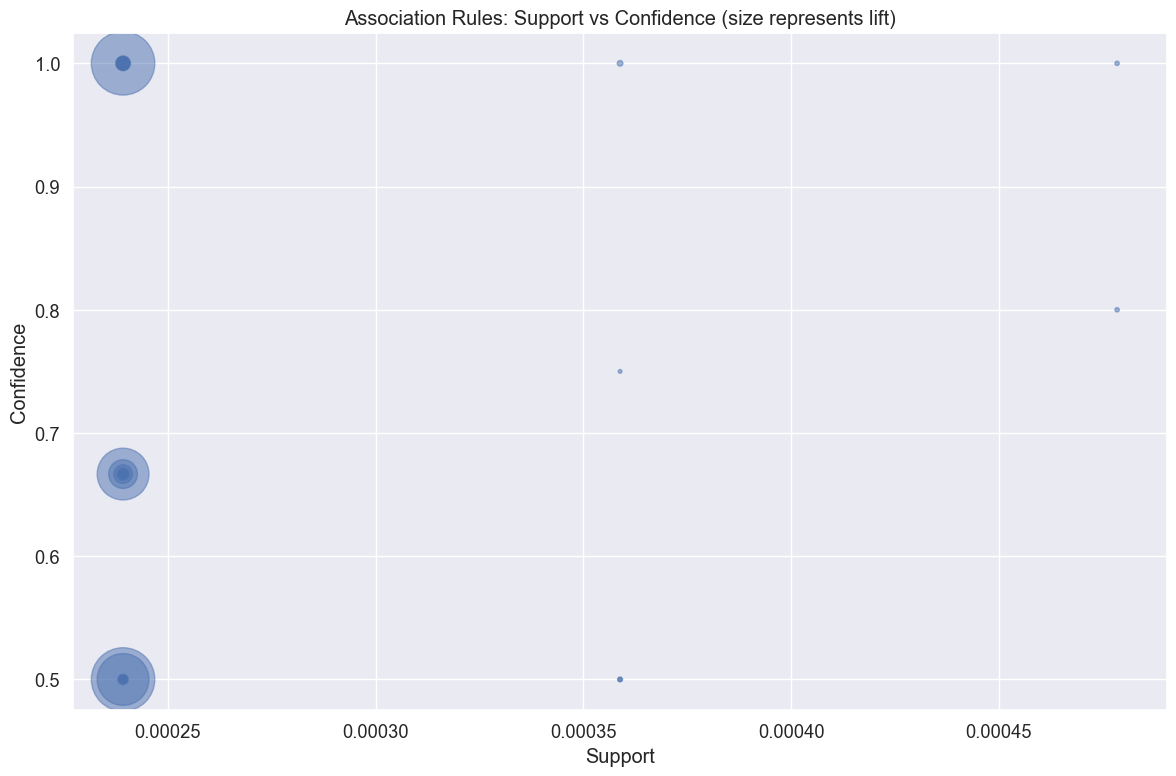

In [172]:
# Visualize rule metrics
rule_df = pd.DataFrame(sorted_rules)

plt.figure(figsize=(12, 8))
plt.scatter(rule_df['support'], rule_df['confidence'], 
            s=rule_df['lift'], alpha=0.5)
plt.title('Association Rules: Support vs Confidence (size represents lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid(True)
plt.tight_layout()
plt.show()

This scatter plot visualizes the association rules with support on the x-axis, confidence on the y-axis, and the size of the circles representing lift values.

The key observations from this visualization:

1. **Support is very low across all rules** - All the rules have support values between 0.00025 and 0.00048, confirming that these patterns appear in a very small fraction of transactions 

2. **Confidence clusters** - There are three main clusters of confidence values:
   - 100% confidence (rules that always hold true when the antecedent occurs)
   - ~67% confidence (rules that hold true in about 2/3 of cases)
   - 50% confidence (rules that hold true in half the cases)

3. **Lift variation** - The larger circles indicate rules with higher lift values. The largest circles appear at the lower support values, suggesting that the highest lift are also the rarest.

4. **Interesting pattern** - Rules with identical support but different confidence levels indicate different association patterns within the same transactions.

This visualization confirms that we've found strong associations (high confidence and lift) but they occur in a very small number of transactions. These represent niche shopping behaviors rather than mainstream patterns, which could be valuable for targeted marketing to specific customer segments or for specialized product recommendations.

The concentrated clusters at the left side of the plot suggest that the majority of our strong rules come from the same few transactions, which further emphasizes the specialized nature of these patterns.

In [181]:
temp_arr = []
for k in frequent_itemsets.keys():
    temp_arr.extend(frequent_itemsets[k])
temp_df = pd.DataFrame(temp_arr, columns=['item_set', 'support'])
temp_df.to_excel("train_frequent_itemsets.xlsx")
temp_df

,item_set,support
0,(shopping bags),0.052745
1,(cleaner),0.002272
2,(bottled water),0.060758
3,(sausage),0.025715
4,(tropical fruit),0.048798
...,...,...
2608,"(soda, canned beer, ham)",0.000239
2609,"(canned beer, domestic eggs, soda)",0.000239
2610,"(newspapers, hard cheese, soda, other vegetables)",0.000239
2611,"(whipped/sour cream, dishes, citrus fruit, fra...",0.000239


In [ ]:
transactions.to_excel("train_transactions.xlsx")

[['cleaner', 'shopping bags'],
 ['sausage', 'bottled water'],
 ['tropical fruit', 'other vegetables'],
 ['whole milk', 'flower (seeds)'],
 ['citrus fruit', 'coffee'],
 ['onions', 'whipped/sour cream', 'dishes'],
 ['other vegetables', 'yogurt'],
 ['berries', 'whipped/sour cream', 'bottled water'],
 ['hamburger meat', 'frozen potato products'],
 ['hamburger meat', 'candles'],
 ['other vegetables', 'yogurt', 'Instant food products'],
 ['hamburger meat', 'bottled beer', 'domestic eggs'],
 ['bottled water', 'Instant food products'],
 ['butter', 'frozen vegetables'],
 ['yogurt', 'shopping bags', 'waffles', 'chocolate'],
 ['yogurt', 'frozen vegetables'],
 ['waffles', 'whole milk'],
 ['soda', 'brown bread'],
 ['sliced cheese', 'bottled water'],
 ['curd', 'soda'],
 ['specialty chocolate', 'frozen vegetables'],
 ['other vegetables', 'white bread'],
 ['pip fruit', 'frozen fish'],
 ['frankfurter', 'sparkling wine'],
 ['sugar', 'cream cheese '],
 ['other vegetables', 'whole milk', 'soda'],
 ['froze

In [190]:

temp_df = pd.DataFrame([(k,v) for k,v in miner.item_support.items()], columns = ['item', 'support'])
temp_df.to_excel("train_item_supp.xlsx")
temp_df

,item,support
0,shopping bags,0.052745
1,cleaner,0.002272
2,bottled water,0.060758
3,sausage,0.025715
4,tropical fruit,0.048798
...,...,...
158,cream,0.000837
159,frozen chicken,0.000239
160,frozen fruits,0.000837
161,flower soil/fertilizer,0.000957


## 3. Advanced Pattern Scoring (to score patterns created from previous step)
Implement our custom pattern scoring metrics

In [267]:
class PatternScorer:
    """
    PatternScorer evaluates frequent itemsets from market basket analysis.
    
    This class provides methods to score patterns using various metrics including
    support, lift, recency, and combinations of these metrics. It can also personalize
    recommendations based on user purchase history.
    """
    def __init__(self, transactions, frequent_itemsets, item_support):
        """
        Initialize the PatternScorer with transaction data and frequent itemsets.
        
        Parameters:
        -----------
        transactions : list
            List of transactions where each transaction is a set of items
        frequent_itemsets : dict
            Dictionary mapping k (itemset size) to list of (itemset, support) tuples
        item_support : dict
            Dictionary mapping individual items to their support values
        """
        self.transactions = transactions
        self.frequent_itemsets = frequent_itemsets
        self.item_support = item_support
        self.user_data = None
    
    def add_user_data(self, data):
        """
        Add user-specific data for personalized scoring.
        
        This method processes user transaction data to calculate:
        1. How frequently each user buys each item
        2. When each user last purchased each item
        
        Parameters:
        -----------
        data : DataFrame
            DataFrame containing user purchase history with User_id, itemDescription, and Date columns
        """
        self.user_data = data
        
        # Initialize dictionaries to track user purchase patterns
        # user_item_frequencies: How many times each user bought each item
        self.user_item_frequencies = defaultdict(lambda: defaultdict(int)) 
        #This dictionary stores user's latest date making purchase on each item
        self.user_last_purchase = defaultdict(lambda: defaultdict(str))
        
        # Group data by user
        for _, row in data.iterrows():
            user = row['User_id']
            item = row['itemDescription']
            date = row['Date']
            
            # FOREACH USER FOREACH ITEM: store how many time they purchased that item and the latest purchase date

            # Update frequency
            self.user_item_frequencies[user][item] += 1
            
            # Update last purchase date if needed (if we found a new record of current user purchasing same item but more recent) 
            if item not in self.user_last_purchase[user] or date > self.user_last_purchase[user][item]:
                self.user_last_purchase[user][item] = date
    
    def score_patterns(self, method='combined', user_id=None, top_n=None):
        """
        Score patterns using various metrics.
        
        This method calculates scores for itemsets based on the specified method.
        It can personalize scores for specific users and return only top N results.
        
        Parameters:
        -----------
        method : str, default='combined'
            Scoring method: 'support', 'lift', 'recency', or 'combined'
        user_id : int, optional
            If provided, personalize scores for this user
        top_n : int, optional
            If provided, return only top N patterns
        
        Returns:
        --------
        list
            Scored patterns as (itemset, score) tuples, sorted by score in descending order
        """
        # Create a flat list of all itemsets with their supports
        all_itemsets = []
        if isinstance(self.frequent_itemsets,dict):
            for k in self.frequent_itemsets:
                all_itemsets.extend([(frozenset(itemset), support) for itemset, support in self.frequent_itemsets[k]])
        
        # Apply scoring method

        #support method
        if method == 'support':
            scored_patterns = [(list(itemset), support) for itemset, support in all_itemsets]
        
        #lift method
        elif method == 'lift':
            scored_patterns = []
            for itemset, support in all_itemsets:
                if len(itemset) <= 1:
                    # For single items, just use support 
                    scored_patterns.append((list(itemset), support))
                else:
                    # Calculate average lift for this pattern
                    avg_lift = self._calculate_pattern_lift(itemset, support)
                    # WEIGHT BY SUPPORT==============
                    # score = avg_lift * support
                    score = avg_lift
                    scored_patterns.append((list(itemset), score))
        
        #recency method
        elif method == 'recency':
            if user_id is None or self.user_data is None:
                raise ValueError("User ID and user data required for recency scoring")
            
            scored_patterns = []
            for itemset, support in all_itemsets:
                # Calculate recency score
                recency_score = self._calculate_recency_score(itemset, user_id)
                # Combine with support
                # score = recency_score * support
                score = recency_score
                scored_patterns.append((list(itemset), score))
        
        # combine confidence + lift + recency (using user data)
        elif method == 'combined':
            # Define weights for different factors
            if user_id:
                w_support = 0.2
                w_lift = 0.2
                w_recency = 0.5
                w_frequency = 0.1
            else:
                w_support = 0.4
                w_lift = 0.3
                w_recency = 0
                w_frequency = 0.3
                
            
            scored_patterns = []
            for itemset, support in all_itemsets:
                # Start with support component
                score_components = [support * w_support]
                
                # Add lift component for multi-item patterns
                if len(itemset) > 1:
                    lift = self._calculate_pattern_lift(itemset, support)
                    score_components.append(lift * w_lift)
                else:
                    # For 1-itemsets, still add the weight
                    score_components.append(w_lift)
                
                # Add user-specific components if available
                if user_id is not None and self.user_data is not None:
                    # Recency component
                    recency = self._calculate_recency_score(itemset, user_id)
                    score_components.append(recency * w_recency)
                    
                    # Frequency component
                    frequency = self._calculate_frequency_score(itemset, user_id)
                    score_components.append(frequency * w_frequency)
                else:
                    # Without user data, add the weights
                    score_components.extend([w_recency, w_frequency])
                
                # Calculate final score
                final_score = sum(score_components)
                scored_patterns.append((list(itemset), final_score))
        
        else:
            raise ValueError(f"Unknown scoring method: {method}")
        
        # Sort by score (descending)
        scored_patterns.sort(key=lambda x: x[1], reverse=True)
        
        # Return top N if specified
        if top_n is not None:
            return scored_patterns[:top_n]
        return scored_patterns
    
    def _calculate_pattern_lift(self, pattern, pattern_support):
        """Calculate average lift across all possible rules from this pattern"""
        if len(pattern) <= 1:
            return 1.0  # No meaningful lift for singleton sets
        
        lifts = []
        
        # For each possible rule A -> B from this pattern
        for i in range(1, len(pattern)): #len(antecedent) from 1 to len(pattern) - 1, antecedent cannot be empty 
            for antecedent_items in combinations(pattern, i):
                antecedent = frozenset(antecedent_items)
                consequent = pattern - antecedent
                
                # Find supports
                antecedent_support = self._get_itemset_support(antecedent)
                consequent_support = self._get_itemset_support(consequent)
                
                if antecedent_support > 0 and consequent_support > 0:
                    # A => B, lift = Supp(A,B)/ (Supp(A) * Supp(B)) = Conf(A,B) / Supp(B)
                    confidence = pattern_support / antecedent_support
                    lift = confidence / consequent_support
                    lifts.append(lift)
        
        # Return average lift
        return sum(lifts) / len(lifts) if lifts else 1.0
    
    def _get_itemset_support(self, itemset):
        """Get support for an itemset"""
        if len(itemset) == 1:
            item = list(itemset)[0]
            return self.item_support.get(item, 0)
        
        # Search in frequent itemsets
        for k in self.frequent_itemsets:
            if k == len(itemset):
                for candidate, support in self.frequent_itemsets[k]:
                    if frozenset(candidate) == itemset:
                        return support
        
        return 0  # Not found (not frequent)
    
    def _calculate_recency_score(self, pattern, user_id):
        """Calculate recency score based on how recently user purchased items"""
        if user_id not in self.user_last_purchase:
            return 0  # Default for users with no history
        
        # Get the latest date a purchase was made by a specific user
        latest_date = max(date for user_dates in self.user_last_purchase.values() 
                         for date in user_dates.values())
        
        # Calculate recency for each item in pattern
        recency_scores = []
        # loop to calculate recency score for this pattern
        for item in pattern:
            if item in self.user_last_purchase[user_id]:
                last_purchase = self.user_last_purchase[user_id][item]
                days_since = (latest_date - last_purchase).days
                
                # Convert to a normalized score (higher is more recent)
                # Using exponential decay: e^(-days/30)
                recency = 30/(days_since) #math.exp(-days_since)
                recency_scores.append(recency)
        
        # Return average recency
        return sum(recency_scores) if recency_scores else 0 # / len(recency_scores) 
    
    def _calculate_frequency_score(self, pattern, user_id):
        """Calculate frequency score based on how often user buys these items"""
        if user_id not in self.user_item_frequencies:
            return 0.5  # Default for users with no history
        
        # Find the maximum frequency across all users and items
        max_freq = max(freq for user_freq in self.user_item_frequencies.values() 
                      for freq in user_freq.values())
        
        # Calculate normalized frequency for each item in pattern
        freq_scores = []
        for item in pattern:
            if item in self.user_item_frequencies[user_id]:
                # Normalize by max frequency
                norm_freq = self.user_item_frequencies[user_id][item] / max_freq
                freq_scores.append(norm_freq)
        
        # Return average frequency
        return sum(freq_scores) / len(freq_scores) if freq_scores else 0.5

In [268]:
# Group by User_id and Date to count transactions per user
transactions_per_user = train_data.groupby(['User_id', 'Date']).size().groupby('User_id').size()

# Find the top 10 users with the most transactions
top_10_users = transactions_per_user.nlargest(10)

print("Top 10 users with the most transactions:")
print(top_10_users)

Top 10 users with the most transactions:
User_id
1169    9
3248    9
1410    8
1466    8
1798    8
1908    8
3221    8
4683    8
4941    8
1004    7
dtype: int64


In [ ]:
# Create pattern scorer and score patterns created from previous step
scorer = PatternScorer(transactions, frequent_itemsets, miner.item_support)
scorer.add_user_data(train_data)
# Get general patterns with combined scoring
general_patterns = scorer.score_patterns(method='combined', top_n=30)
print("Top 20 patterns by combined score:")
for i, (pattern, score) in enumerate(general_patterns, 1):
    print(f"{i}. {pattern} (score: {score:.4f})")


Top 20 patterns by combined score:
1. ['whipped/sour cream', 'dishes', 'citrus fruit', 'frankfurter'] (score: 178.5405)
2. ['vinegar', 'grapes', 'frozen vegetables'] (score: 32.1123)
3. ['dishes', 'citrus fruit', 'frankfurter'] (score: 17.9583)
4. ['newspapers', 'hard cheese', 'soda', 'other vegetables'] (score: 14.5682)
5. ['flower (seeds)', 'honey'] (score: 12.1597)
6. ['whipped/sour cream', 'dishes', 'frankfurter'] (score: 11.5504)
7. ['jam', 'house keeping products'] (score: 10.0790)
8. ['rolls/buns', 'ham', 'pickled vegetables'] (score: 8.2167)
9. ['brown bread', 'sugar', 'frankfurter'] (score: 7.2719)
10. ['cocoa drinks', 'canned fish'] (score: 7.0793)
11. ['ham', 'soda', 'pickled vegetables'] (score: 6.5300)
12. ['flower (seeds)', 'pork', 'whole milk'] (score: 6.0760)
13. ['newspapers', 'white bread', 'specialty bar'] (score: 6.0405)
14. ['cookware', 'oil'] (score: 6.0334)
15. ['liver loaf', 'processed cheese'] (score: 5.8990)
16. ['soft cheese', 'hamburger meat', 'whole milk'] 

In [274]:
# Get patterns for a specific user
validation_user_ids = [1169, 3248, 1410,1466,1798,1908,3221,4683,4941,1004]
sample_user_id = 4941 # Just using the first user as an example
user_patterns = scorer.score_patterns(method='combined', user_id=sample_user_id, top_n=30)

print(f"\nTop 10 patterns for user {sample_user_id}:")
for i, (pattern, score) in enumerate(user_patterns, 1):
    print(f"{i}. {pattern} (score: {score:.4f})")


Top 10 patterns for user 4941:
1. ['whipped/sour cream', 'dishes', 'citrus fruit', 'frankfurter'] (score: 118.8770)
2. ['vinegar', 'grapes', 'frozen vegetables'] (score: 21.2582)
3. ['rolls/buns', 'ham', 'pickled vegetables'] (score: 14.2978)
4. ['ham', 'soda', 'pickled vegetables'] (score: 13.1866)
5. ['newspapers', 'hard cheese', 'soda', 'other vegetables'] (score: 12.6053)
6. ['dishes', 'citrus fruit', 'frankfurter'] (score: 11.8222)
7. ['soda', 'canned beer', 'ham'] (score: 10.8046)
8. ['hamburger meat', 'domestic eggs', 'bottled beer'] (score: 10.8014)
9. ['salty snack', 'domestic eggs', 'soda'] (score: 9.9892)
10. ['canned beer', 'domestic eggs', 'soda'] (score: 9.6245)
11. ['rolls/buns', 'soda', 'canned beer'] (score: 9.2996)
12. ['rolls/buns', 'soda', 'bottled beer'] (score: 9.2682)
13. ['flower (seeds)', 'honey'] (score: 7.9564)
14. ['whipped/sour cream', 'dishes', 'frankfurter'] (score: 7.5502)
15. ['ham', 'pickled vegetables'] (score: 7.0769)
16. ['soft cheese', 'hamburger 

## 4. Evaluating Pattern Quality   
evaluate mined patterns' quality

In [279]:
#Evaluate if patterns are meaningful
def evaluate_pattern_quality(patterns, transactions):
    """Calculate coverage and redundancy metrics for patterns"""
    # Calculate coverage (what percentage of transactions contain at least one pattern)
    covered_transactions = 0
    for transaction in transactions:
        transaction_set = set(transaction)
        is_covered = False
        for pattern, _ in patterns:
            pattern_set = set(pattern)
            if pattern_set.issubset(transaction_set):
                is_covered = True
                break
        if is_covered:
            covered_transactions += 1
    
    coverage = covered_transactions / len(transactions)
    
    # Calculate redundancy (average Jaccard similarity between patterns)
    similarities = []
    for i, (pattern1, _) in enumerate(patterns):
        for j, (pattern2, _) in enumerate(patterns):
            if i < j:  # Only compare each pair once
                set1 = set(pattern1)
                set2 = set(pattern2)
                
                # Jaccard similarity
                intersection = len(set1.intersection(set2))
                union = len(set1.union(set2))
                if union > 0:
                    similarity = intersection / union
                    similarities.append(similarity)
    
    redundancy = sum(similarities) / len(similarities) if similarities else 0
    
    return {
        'coverage': coverage,
        'redundancy': redundancy
    }

In [280]:
# Evaluate our pattern quality
pattern_quality = evaluate_pattern_quality(general_patterns, transactions)
print(f"Pattern quality metrics:")
print(f"Coverage: {pattern_quality['coverage']:.4f}") # (higher is better)
print(f"Redundancy: {pattern_quality['redundancy']:.4f}") # (lower is better)


Pattern quality metrics:
Coverage: 0.0062
Redundancy: 0.0327


## 5. Conclusion and Pattern Mining Module

In [289]:
class FrequentPatternMiner:
    """
    A class for mining and scoring frequent patterns from grocery transaction data.
    """
    
    def __init__(self, min_support=0.005, min_confidence=0.3):
        """
        Initialize the pattern miner.
        
        Parameters:
        -----------
        min_support : float, default=0.005
            Minimum support threshold (between 0 and 1)
        min_confidence : float, default=0.3
            Minimum confidence threshold for association rules
        """
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.apriori_miner = None
        self.pattern_scorer = None
        self.transactions = None
    def prepare_transactions(self, data):
        """
        Convert raw data to transaction format.
        
        Parameters:
        -----------
        data : pandas.DataFrame
            Raw input data
        
        Returns:
        --------
        list of lists
            Transactions in the right format for pattern mining
        """
        # Group by user and date
        transactions = defaultdict(list)
        for _, row in data.iterrows():
            key = (row['User_id'], row['Date'])
            if pd.notna(row['itemDescription']):  # Skip null items
                transactions[key].append(row['itemDescription'])
        
        # Convert to list of lists
        transaction_list = list(transactions.values())
        return transaction_list
    
    def fit(self, data, user_id=None):
        """
        Mine frequent patterns from the data.
        
        Parameters:
        -----------
        data : pandas.DataFrame
            Raw input data
        user_id : int, optional
            If provided, focus on this user's data
        
        Returns:
        --------
        self
        """
        # Prepare transactions
        if user_id is not None:
            # Filter data for specific user
            user_data = data[data['User_id'] == user_id]
            if len(user_data) > 0:
                self.transactions = self.prepare_transactions(user_data)
            else:
                # User has no data, use all data
                self.transactions = self.prepare_transactions(data)
        else:
            self.transactions = self.prepare_transactions(data)
        
        # Run Apriori
        self.apriori_miner = AprioriMiner(min_support=self.min_support)
        frequent_itemsets = self.apriori_miner.fit(self.transactions)
        
        # Create pattern scorer
        self.pattern_scorer = PatternScorer(
            self.transactions, 
            frequent_itemsets, 
            self.apriori_miner.item_support
        )
        self.pattern_scorer.add_user_data(data)
        
        return self
    
    def get_patterns(self, method='combined', user_id=None, top_n=10):
        """
        Get scored patterns.
        
        Parameters:
        -----------
        method : str, default='combined'
            Scoring method: 'support', 'lift', 'recency', or 'combined'
        user_id : int, optional
            If provided, personalize scores for this user
        top_n : int, default=10
            Number of patterns to return
        
        Returns:
        --------
        list
            List of (pattern, score) tuples
        """
        if self.pattern_scorer is None:
            raise ValueError("You must call fit() before get_patterns()")
        
        return self.pattern_scorer.score_patterns(
            method=method, 
            user_id=user_id, 
            top_n=top_n
        )
    
    def get_rules(self, top_n=20):
        """
        Get association rules.
        
        Parameters:
        -----------
        top_n : int, default=20
            Number of rules to return
            
        Returns:
        --------
        list
            List of association rules
        """
        if self.apriori_miner is None:
            raise ValueError("You must call fit() before get_rules()")
        
        rules = self.apriori_miner.generate_rules(min_confidence=self.min_confidence)
        
        # Sort by lift
        sorted_rules = sorted(rules, key=lambda x: x['lift'], reverse=True)
        
        return sorted_rules[:top_n]

In [291]:
# Example usage of the final module
# Create an instance
miner = FrequentPatternMiner(min_support=0.02/100, min_confidence=0.5)

# Fit the model
miner.fit(train_data,user_id=None)

# Get top patterns with combined scoring
top_patterns = miner.get_patterns(method='combined', top_n=15)
print("Top 15 patterns with combined scoring:")
for i, (pattern, score) in enumerate(top_patterns, 1):
    print(f"{i}. {pattern} (score: {score:.4f})")

# Get top association rules
top_rules = miner.get_rules(top_n=10)
print("\nTop 10 association rules by lift:")
for i, rule in enumerate(top_rules, 1):
    print(f"{i}. {rule['antecedent']} => {rule['consequent']} "
          f"(support: {rule['support']:.4f}, confidence: {rule['confidence']:.4f}, lift: {rule['lift']:.4f})")

Top 15 patterns with combined scoring:
1. ['whipped/sour cream', 'dishes', 'citrus fruit', 'frankfurter'] (score: 178.5405)
2. ['vinegar', 'grapes', 'frozen vegetables'] (score: 32.1123)
3. ['dishes', 'citrus fruit', 'frankfurter'] (score: 17.9583)
4. ['newspapers', 'hard cheese', 'soda', 'other vegetables'] (score: 14.5682)
5. ['flower (seeds)', 'honey'] (score: 12.1597)
6. ['whipped/sour cream', 'dishes', 'frankfurter'] (score: 11.5504)
7. ['jam', 'house keeping products'] (score: 10.0790)
8. ['rolls/buns', 'ham', 'pickled vegetables'] (score: 8.2167)
9. ['brown bread', 'sugar', 'frankfurter'] (score: 7.2719)
10. ['cocoa drinks', 'canned fish'] (score: 7.0793)
11. ['ham', 'soda', 'pickled vegetables'] (score: 6.5300)
12. ['flower (seeds)', 'pork', 'whole milk'] (score: 6.0760)
13. ['newspapers', 'white bread', 'specialty bar'] (score: 6.0405)
14. ['cookware', 'oil'] (score: 6.0334)
15. ['liver loaf', 'processed cheese'] (score: 5.8990)

Top 10 association rules by lift:
1. ['whipped/

## 6. Analyzing Pattern Mining Results

c:\Users\ASUS\.conda\envs\myenv\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


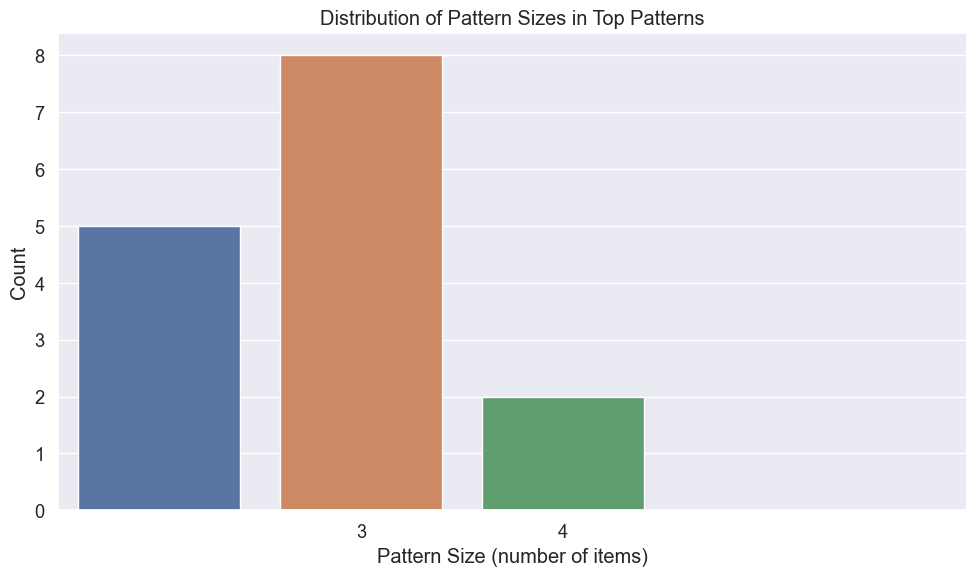

In [197]:
# Visualize pattern sizes
pattern_sizes = [len(pattern) for pattern, _ in top_patterns]

plt.figure(figsize=(10, 6))
sns.countplot(x=pattern_sizes)
plt.title('Distribution of Pattern Sizes in Top Patterns')
plt.xlabel('Pattern Size (number of items)')
plt.ylabel('Count')
plt.xticks(range(1, max(pattern_sizes)+1))
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

c:\Users\ASUS\.conda\envs\myenv\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


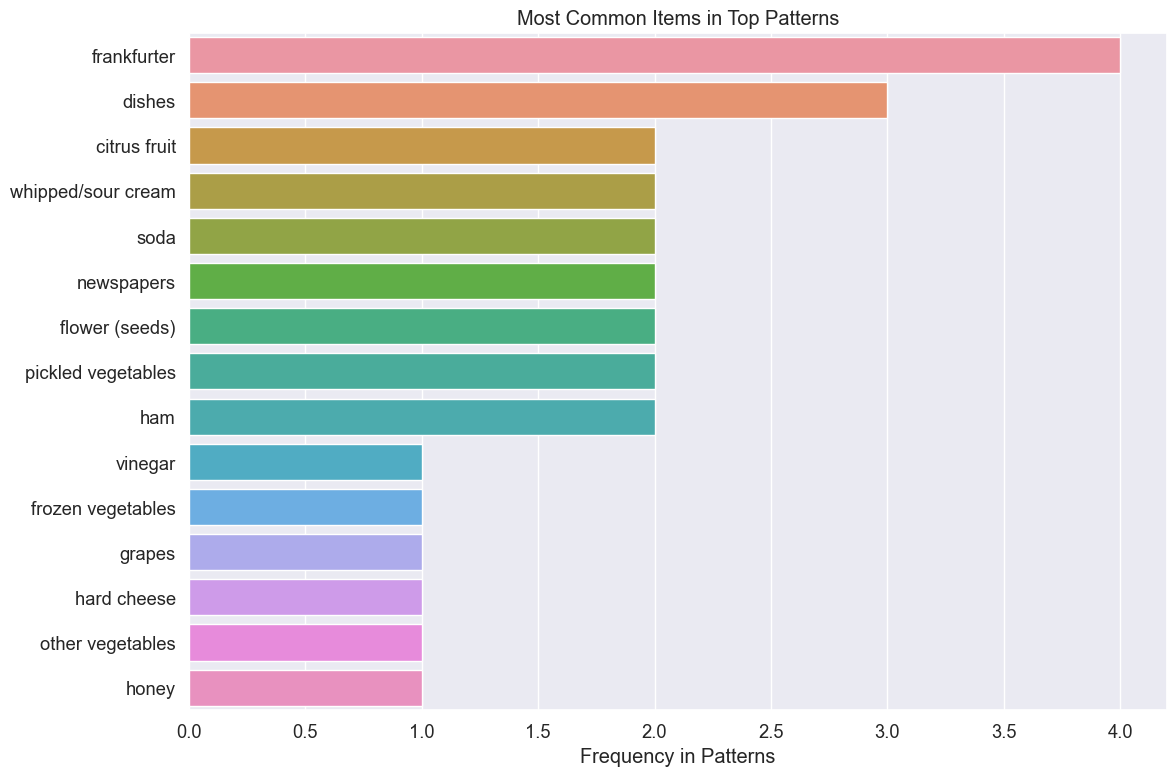

In [198]:
# Analyze item frequency in top patterns
item_in_patterns = defaultdict(int)
for pattern, _ in top_patterns:
    for item in pattern:
        item_in_patterns[item] += 1

# Plot top items in patterns
top_pattern_items = sorted(item_in_patterns.items(), key=lambda x: x[1], reverse=True)[:15]
item_names = [item for item, _ in top_pattern_items]
item_counts = [count for _, count in top_pattern_items]

plt.figure(figsize=(12, 8))
sns.barplot(x=item_counts, y=item_names)
plt.title('Most Common Items in Top Patterns')
plt.xlabel('Frequency in Patterns')
plt.tight_layout()
plt.show()

## 7. User-Specific Pattern Analysis

Let's analyze patterns for specific users:

In [301]:


# Analyze patterns for each user
for user_id in list(top_10_users.index):
    # Get user data
    user_data = train_data[train_data['User_id'] == user_id]
    print(f"\nUser {user_id}: {len(user_data)} items in {user_data['Date'].nunique()} transactions")
    
    # Get user's top purchased items
    top_items = user_data['itemDescription'].value_counts().head(5)
    print("Top 5 purchased items:")
    for item, count in top_items.items():
        print(f"  - {item}: {count} times")
    
    # Get personalized patterns
    user_patterns = miner.get_patterns(method='combined', user_id=user_id, top_n=5)
    print("Top 5 personalized patterns:")
    for i, (pattern, score) in enumerate(user_patterns, 1):
        print(f"  {i}. {pattern} (score: {score:.4f})")
    
    print("-" * 50)


User 1169: 21 items in 9 transactions
Top 5 purchased items:
  - napkins: 3 times
  - soda: 2 times
  - other vegetables: 2 times
  - bottled water: 1 times
  - cake bar: 1 times
Top 5 personalized patterns:
  1. ['whipped/sour cream', 'dishes', 'citrus fruit', 'frankfurter'] (score: 118.9106)
  2. ['vinegar', 'grapes', 'frozen vegetables'] (score: 21.2582)
  3. ['dishes', 'citrus fruit', 'frankfurter'] (score: 11.8222)
  4. ['newspapers', 'hard cheese', 'soda', 'other vegetables'] (score: 9.6937)
  5. ['flower (seeds)', 'honey'] (score: 7.9564)
--------------------------------------------------

User 3248: 19 items in 9 transactions
Top 5 purchased items:
  - other vegetables: 3 times
  - chicken: 2 times
  - UHT-milk: 1 times
  - processed cheese: 1 times
  - liquor: 1 times
Top 5 personalized patterns:
  1. ['whipped/sour cream', 'dishes', 'citrus fruit', 'frankfurter'] (score: 118.8770)
  2. ['vinegar', 'grapes', 'frozen vegetables'] (score: 21.2582)
  3. ['dishes', 'citrus fruit'

## 8. Pattern Scoring Comparison

In [303]:
# Compare different scoring methods
scoring_methods = ['support', 'lift', 'combined']
user_id = 4941 # Use the first sample user

print(f"Comparing scoring methods for user {user_id}:")
for method in scoring_methods:
    patterns = miner.get_patterns(method=method, user_id=user_id, top_n=5)
    
    print(f"\nTop 5 patterns using {method} scoring:")
    for i, (pattern, score) in enumerate(patterns, 1):
        print(f"  {i}. {pattern} (score: {score:.4f})")

Comparing scoring methods for user 4941:

Top 5 patterns using support scoring:
  1. ['whole milk'] (score: 0.1305)
  2. ['other vegetables'] (score: 0.1067)
  3. ['rolls/buns'] (score: 0.1019)
  4. ['soda'] (score: 0.0946)
  5. ['yogurt'] (score: 0.0786)

Top 5 patterns using lift scoring:
  1. ['whipped/sour cream', 'dishes', 'citrus fruit', 'frankfurter'] (score: 594.1348)
  2. ['vinegar', 'grapes', 'frozen vegetables'] (score: 106.0407)
  3. ['dishes', 'citrus fruit', 'frankfurter'] (score: 58.8607)
  4. ['newspapers', 'hard cheese', 'soda', 'other vegetables'] (score: 47.5603)
  5. ['flower (seeds)', 'honey'] (score: 39.5319)

Top 5 patterns using combined scoring:
  1. ['whipped/sour cream', 'dishes', 'citrus fruit', 'frankfurter'] (score: 118.8770)
  2. ['vinegar', 'grapes', 'frozen vegetables'] (score: 21.2582)
  3. ['rolls/buns', 'ham', 'pickled vegetables'] (score: 14.2978)
  4. ['ham', 'soda', 'pickled vegetables'] (score: 13.1866)
  5. ['newspapers', 'hard cheese', 'soda', 

## 9. Recency Effect Analysis

analyze the effect of recency on pattern scoring:

In [304]:
# Analyze how recency affects pattern ranking
user_id = 4941  # Use the first sample user

# Get user purchase history
user_data = train_data[train_data['User_id'] == user_id]
user_dates = sorted(user_data['Date'].unique())

if len(user_dates) >= 2:
    # Split into early and recent purchases
    split_point = len(user_dates) // 2
    early_dates = user_dates[:split_point]
    recent_dates = user_dates[split_point:]
    
    early_purchases = user_data[user_data['Date'].isin(early_dates)]
    recent_purchases = user_data[user_data['Date'].isin(recent_dates)]
    
    print(f"\nAnalyzing recency effect for user {user_id}:")
    print(f"Early purchases ({early_dates[0]} to {early_dates[-1]}): {len(early_purchases)} items")
    print(f"Recent purchases ({recent_dates[0]} to {recent_dates[-1]}): {len(recent_purchases)} items")
    
    # Compare top items
    early_items = early_purchases['itemDescription'].value_counts().head(5)
    recent_items = recent_purchases['itemDescription'].value_counts().head(5)
    
    print("\nTop 5 items in early purchases:")
    for item, count in early_items.items():
        print(f"  - {item}: {count} times")
    
    print("\nTop 5 items in recent purchases:")
    for item, count in recent_items.items():
        print(f"  - {item}: {count} times")
    
    # Compare with recency-weighted patterns
    recency_patterns = miner.get_patterns(method='recency', user_id=user_id, top_n=5)
    
    print("\nTop 5 patterns with recency scoring:")
    for i, (pattern, score) in enumerate(recency_patterns, 1):
        # Check if pattern items are in recent purchases
        in_recent = sum(1 for item in pattern if item in recent_items)
        print(f"  {i}. {pattern} (score: {score:.4f}, items in recent purchases: {in_recent}/{len(pattern)})")


Analyzing recency effect for user 4941:
Early purchases (2014-02-24 00:00:00 to 2014-08-13 00:00:00): 8 items
Recent purchases (2014-09-09 00:00:00 to 2015-01-15 00:00:00): 15 items

Top 5 items in early purchases:
  - white wine: 1 times
  - soda: 1 times
  - liquor: 1 times
  - newspapers: 1 times
  - yogurt: 1 times

Top 5 items in recent purchases:
  - soda: 2 times
  - canned beer: 2 times
  - coffee: 1 times
  - white bread: 1 times
  - chocolate marshmallow: 1 times

Top 5 patterns with recency scoring:
  1. ['hamburger meat', 'domestic eggs', 'bottled beer'] (score: 18.0000, items in recent purchases: 0/3)
  2. ['ham', 'soda', 'pickled vegetables'] (score: 18.0000, items in recent purchases: 1/3)
  3. ['rolls/buns', 'soda', 'bottled beer'] (score: 18.0000, items in recent purchases: 1/3)
  4. ['salty snack', 'domestic eggs', 'soda'] (score: 18.0000, items in recent purchases: 1/3)
  5. ['rolls/buns', 'soda', 'canned beer'] (score: 18.0000, items in recent purchases: 2/3)


https://www.geeksforgeeks.org/apriori-algorithm/  
https://www.geeksforgeeks.org/frequent-item-set-in-data-set-association-rule-mining/ 